Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All modules imported successfully!
Current directory: /content/drive/MyDrive/MBP_PREDICTOR

LOADING CLEANED DATASET
Dataset shape: (3072, 3)
Columns: ['Protein_ID', 'Sequence', 'Label']

Class distribution:
Label
0    1539
1    1533
Name: count, dtype: int64
Balance ratio: 0.996

Sequence length statistics:
Min: 31
Max: 2474
Mean: 679.7
Median: 566.0

FEATURE EXTRACTION USING EXISTING MODULES
Initializing ProtBERT embedder...
Loading model Rostlab/prot_bert on cuda...


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Embedder loaded successfully!

Extracting features for 3072 sequences...



Processing sequences: 100%|██████████| 3072/3072 [10:02<00:00,  5.10it/s]



Creating feature matrix...
Ensuring proper data types...
Feature extraction completed!
Original sequences: 3072
Successfully processed: 3072
Failed sequences: 0
Total features per sequence: 1055
Features saved to: data/features_cleaned_with_embeddings.csv

FEATURE ANALYSIS
Final feature matrix shape: (3072, 1057)
Memory usage: 24.9 MB

Feature breakdown:
  AAC features (amino acid composition): 20
  Charge features: 1
  Hydrophobicity features: 3
  pI features: 1
  Motif features: 6
  Embedding features: 1024

No missing values found!

Final class distribution:
Label
0    1539
1    1533
Name: count, dtype: int64

pI statistics:
  Min: 4.05
  Max: 12.00
  Mean: 6.93
  Data type: float64

SAMPLE FEATURE VISUALIZATION


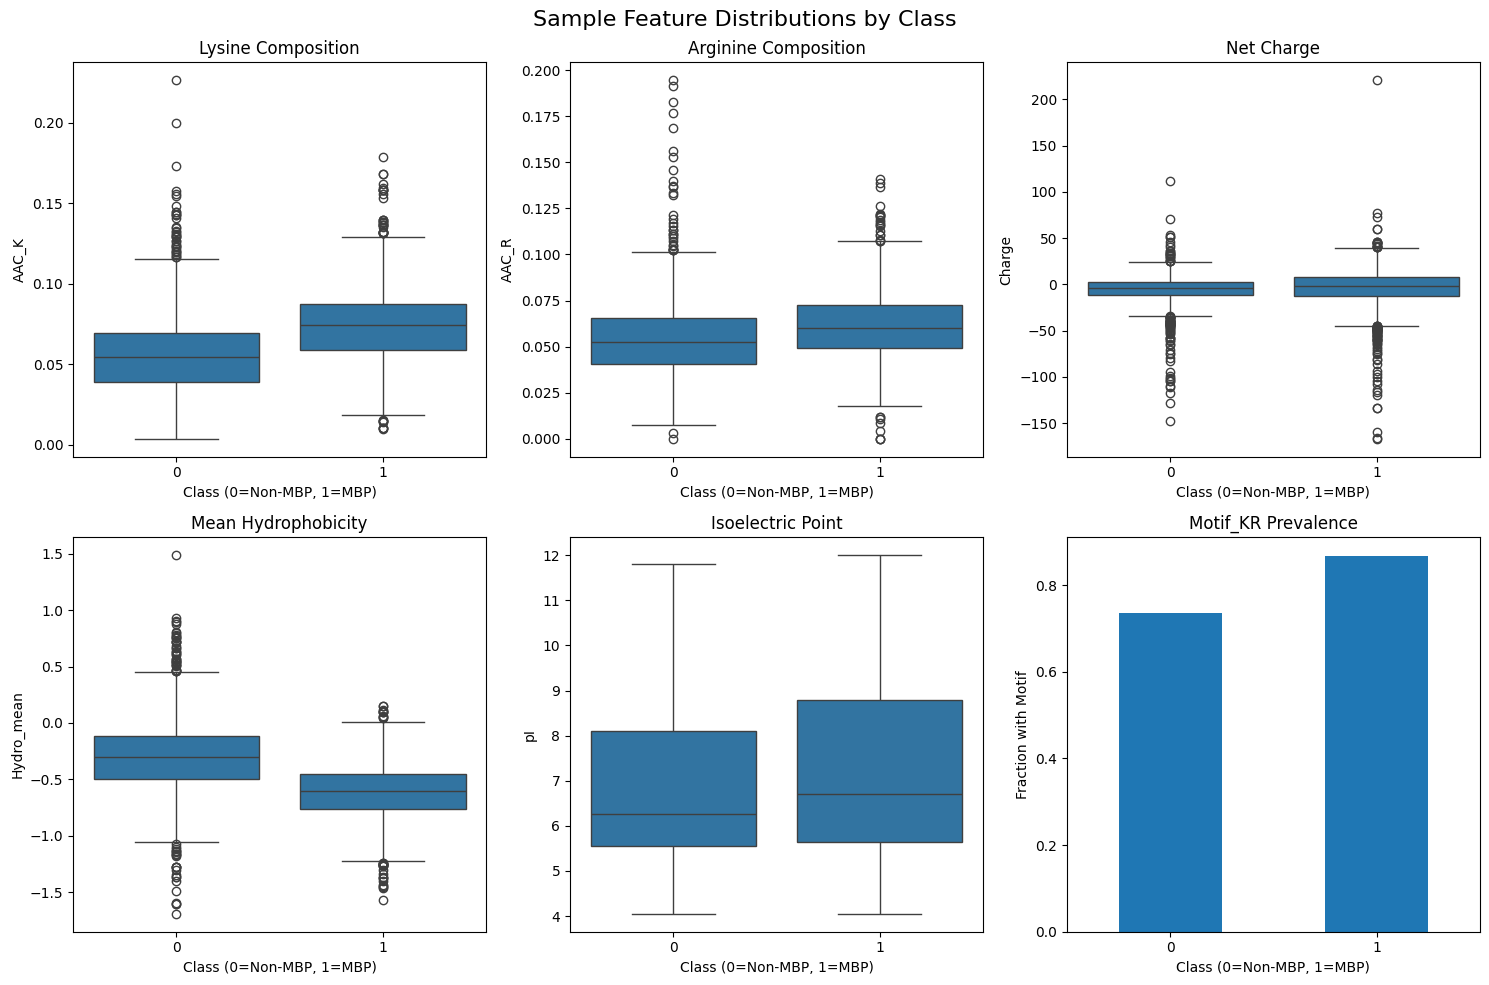


Embedding feature statistics (first 10 dimensions):
E_0: mean=0.113, std=0.048
E_1: mean=0.042, std=0.031
E_2: mean=0.082, std=0.023
E_3: mean=-0.164, std=0.048
E_4: mean=0.203, std=0.052
E_5: mean=-0.025, std=0.027
E_6: mean=-0.104, std=0.024
E_7: mean=0.026, std=0.025
E_8: mean=-0.035, std=0.036
E_9: mean=-0.113, std=0.036

Key feature means by class:
       AAC_K  AAC_R  Charge     pI  Hydro_mean
Label                                         
0      0.056  0.054  -5.702  6.730      -0.302
1      0.075  0.061  -3.861  7.137      -0.611

FEATURE EXTRACTION SUMMARY
COMPLETED SUCCESSFULLY!
Input: 3072 cleaned protein sequences
Output: 3072 x 1055 feature matrix
Saved as: data/features_cleaned_with_embeddings.csv
Ready for machine learning!

Next steps:
1. Load features: pd.read_csv('data/features_cleaned_with_embeddings.csv')
2. Split train/test sets
3. Train ML models (XGBoost, Random Forest, etc.)
4. Evaluate performance

Feature extraction complete! Your dataset is ready for ML mode

In [ ]:
# Feature Extraction Notebook - MBP Dataset (CORRECTED VERSION)
# Using existing modular feature extraction functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive and navigate to project directory
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')

# Add the current directory to Python path to ensure proper imports
import sys
sys.path.append('/content/drive/MyDrive/MBP_PREDICTOR')

# Import your existing feature extraction modules
from src.utils import load_dataset, save_features
from src.feature_aac import compute_aac
from src.feature_charge import compute_charge
from src.feature_hydrophobicity import compute_hydrophobicity
from src.feature_embeddings import ProteinEmbedder
from src.feature_pi import compute_pi
from src.feature_motif import compute_motif

print("All modules imported successfully!")
print(f"Current directory: {os.getcwd()}")

# =============================================================================
# 1. LOAD CLEANED DATASET
# =============================================================================

print("\n" + "="*60)
print("LOADING CLEANED DATASET")
print("="*60)

# Load the cleaned dataset
df = load_dataset("data/mbp_dataset_cleaned.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['Label'].value_counts())
print(f"Balance ratio: {df['Label'].value_counts()[1] / df['Label'].value_counts()[0]:.3f}")

# Quick sequence stats
seq_lengths = df['Sequence'].str.len()
print(f"\nSequence length statistics:")
print(f"Min: {seq_lengths.min()}")
print(f"Max: {seq_lengths.max()}")
print(f"Mean: {seq_lengths.mean():.1f}")
print(f"Median: {seq_lengths.median():.1f}")

# =============================================================================
# 2. RUN FEATURE EXTRACTION USING YOUR EXISTING PIPELINE
# =============================================================================

print("\n" + "="*60)
print("FEATURE EXTRACTION USING EXISTING MODULES")
print("="*60)

# Initialize embedder only once (expensive operation)
print("Initializing ProtBERT embedder...")
try:
    embedder = ProteinEmbedder()
    print("Embedder loaded successfully!")
except Exception as e:
    print(f"Warning: Could not load embedder: {e}")
    print("Continuing without embeddings...")
    embedder = None

print(f"\nExtracting features for {len(df)} sequences...")

all_features = []
failed_sequences = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing sequences"):
    seq = row["Sequence"]
    protein_id = row["Protein_ID"]
    label = row["Label"]

    try:
        features = {}

        # Use your existing feature extraction functions

        # AAC features (20 features) - returns dictionary
        try:
            features.update(compute_aac(seq))
        except Exception as e:
            print(f"AAC failed for {protein_id}: {e}")

        # Charge features (1 feature) - returns dictionary
        try:
            features.update(compute_charge(seq))
        except Exception as e:
            print(f"Charge failed for {protein_id}: {e}")

        # Hydrophobicity features (3 features) - returns dictionary
        try:
            features.update(compute_hydrophobicity(seq))
        except Exception as e:
            print(f"Hydrophobicity failed for {protein_id}: {e}")

        # pI features (1 feature) - returns single float, NOT dictionary
        try:
            pi_value = compute_pi(seq)
            if pi_value is not None:
                features["pI"] = float(pi_value)
            else:
                features["pI"] = 7.0  # Default neutral pH
        except Exception as e:
            print(f"pI failed for {protein_id}: {e}")
            features["pI"] = 7.0

        # Motif features (6 features) - returns dictionary
        try:
            features.update(compute_motif(seq))
        except Exception as e:
            print(f"Motif failed for {protein_id}: {e}")

        # Embeddings using your existing ProteinEmbedder (1024 features)
        if embedder is not None:
            try:
                embedding_vector = embedder.get_embedding(seq)
                embedding_features = {f"E_{i}": float(val) for i, val in enumerate(embedding_vector)}
                features.update(embedding_features)
            except Exception as e:
                print(f"Embedding failed for {protein_id}: {str(e)[:50]}...")
                # Add zero embeddings as fallback
                embedding_features = {f"E_{i}": 0.0 for i in range(1024)}
                features.update(embedding_features)
                failed_sequences.append((protein_id, "embedding_failed"))

        # Add metadata
        features["Label"] = int(label)
        features["Protein_ID"] = protein_id

        all_features.append(features)

    except Exception as e:
        print(f"Complete failure for {protein_id}: {str(e)}")
        failed_sequences.append((protein_id, str(e)))
        continue

# =============================================================================
# 3. CREATE FEATURE DATAFRAME AND SAVE
# =============================================================================

print(f"\nCreating feature matrix...")
feature_df = pd.DataFrame(all_features)

# Ensure all numeric columns are properly typed
print("Ensuring proper data types...")
numeric_cols = [col for col in feature_df.columns if col not in ['Label', 'Protein_ID']]
for col in numeric_cols:
    try:
        feature_df[col] = pd.to_numeric(feature_df[col], errors='coerce')
    except:
        print(f"Warning: Could not convert {col} to numeric")

# Convert Label to int
feature_df['Label'] = feature_df['Label'].astype(int)

# Summary statistics
print(f"Feature extraction completed!")
print(f"Original sequences: {len(df)}")
print(f"Successfully processed: {len(feature_df)}")
print(f"Failed sequences: {len(failed_sequences)}")
print(f"Total features per sequence: {len(feature_df.columns) - 2}")  # exclude Label and Protein_ID

if failed_sequences:
    print(f"\nFailed sequences:")
    for pid, error in failed_sequences[:5]:  # show first 5
        print(f"  {pid}: {error}")
    if len(failed_sequences) > 5:
        print(f"  ... and {len(failed_sequences) - 5} more")

# Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save features using your existing save function
output_filename = "data/features_cleaned_with_embeddings.csv" if embedder else "data/features_cleaned_no_embeddings.csv"
save_features(feature_df, output_filename)
print(f"Features saved to: {output_filename}")

# =============================================================================
# 4. FEATURE ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)

print(f"Final feature matrix shape: {feature_df.shape}")
print(f"Memory usage: {feature_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Feature categories
feature_cols = [col for col in feature_df.columns if col not in ['Label', 'Protein_ID']]
print(f"\nFeature breakdown:")
print(f"  AAC features (amino acid composition): {len([c for c in feature_cols if c.startswith('AAC_')])}")
print(f"  Charge features: {len([c for c in feature_cols if 'Charge' in c])}")
print(f"  Hydrophobicity features: {len([c for c in feature_cols if c.startswith('Hydro_')])}")
print(f"  pI features: {len([c for c in feature_cols if c == 'pI'])}")
print(f"  Motif features: {len([c for c in feature_cols if c.startswith('Motif_')])}")
print(f"  Embedding features: {len([c for c in feature_cols if c.startswith('E_')])}")

# Check for missing values
missing_counts = feature_df.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\nMissing values found:")
    print(missing_counts[missing_counts > 0].head())
else:
    print(f"\nNo missing values found!")

# Class distribution in final dataset
print(f"\nFinal class distribution:")
print(feature_df['Label'].value_counts())

# Quick statistics on key features
if 'pI' in feature_df.columns:
    print(f"\npI statistics:")
    print(f"  Min: {feature_df['pI'].min():.2f}")
    print(f"  Max: {feature_df['pI'].max():.2f}")
    print(f"  Mean: {feature_df['pI'].mean():.2f}")
    print(f"  Data type: {feature_df['pI'].dtype}")

# =============================================================================
# 5. VISUALIZE SAMPLE FEATURES
# =============================================================================

print("\n" + "="*60)
print("SAMPLE FEATURE VISUALIZATION")
print("="*60)

# Helper function for safe plotting
def safe_boxplot(data, x, y, ax, title):
    try:
        if y in data.columns and data[y].notna().sum() > 0:
            sns.boxplot(data=data, x=x, y=y, ax=ax)
            ax.set_title(title)
            ax.set_xlabel('Class (0=Non-MBP, 1=MBP)')
            return True
        else:
            ax.text(0.5, 0.5, f'{y} not available', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{title} - N/A')
            return False
    except Exception as e:
        print(f"Error plotting {y}: {e}")
        ax.text(0.5, 0.5, f'Plotting error', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{title} - Error')
        return False

# Select some key features for visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Feature Distributions by Class', fontsize=16)

# AAC features - Lysine and Arginine (important for MBPs)
safe_boxplot(feature_df, 'Label', 'AAC_K', axes[0,0], 'Lysine Composition')
safe_boxplot(feature_df, 'Label', 'AAC_R', axes[0,1], 'Arginine Composition')
safe_boxplot(feature_df, 'Label', 'Charge', axes[0,2], 'Net Charge')
safe_boxplot(feature_df, 'Label', 'Hydro_mean', axes[1,0], 'Mean Hydrophobicity')
safe_boxplot(feature_df, 'Label', 'pI', axes[1,1], 'Isoelectric Point')

# Sample motif
motif_cols = [c for c in feature_df.columns if c.startswith('Motif_')]
if motif_cols:
    try:
        motif_counts = feature_df.groupby('Label')[motif_cols[0]].mean()
        motif_counts.plot(kind='bar', ax=axes[1,2])
        axes[1,2].set_title(f'{motif_cols[0]} Prevalence')
        axes[1,2].set_xlabel('Class (0=Non-MBP, 1=MBP)')
        axes[1,2].set_ylabel('Fraction with Motif')
        axes[1,2].tick_params(axis='x', rotation=0)
    except Exception as e:
        print(f"Error plotting motif: {e}")
        axes[1,2].text(0.5, 0.5, f'Motif plot error', ha='center', va='center', transform=axes[1,2].transAxes)
        axes[1,2].set_title('Motif Features - Error')
else:
    axes[1,2].text(0.5, 0.5, 'No motif features available', ha='center', va='center', transform=axes[1,2].transAxes)
    axes[1,2].set_title('Motif Features - N/A')

plt.tight_layout()
plt.show()

# Sample embedding visualization
embedding_cols = [c for c in feature_df.columns if c.startswith('E_')]
if len(embedding_cols) > 0:
    print("\nEmbedding feature statistics (first 10 dimensions):")
    for col in embedding_cols[:10]:
        print(f"{col}: mean={feature_df[col].mean():.3f}, std={feature_df[col].std():.3f}")
else:
    print("\nNo embedding features available.")

# Show key feature statistics by class
key_features = ['AAC_K', 'AAC_R', 'Charge', 'pI', 'Hydro_mean']
available_features = [f for f in key_features if f in feature_df.columns]

if available_features:
    print(f"\nKey feature means by class:")
    stats_by_class = feature_df.groupby('Label')[available_features].mean()
    print(stats_by_class.round(3))

# =============================================================================
# 6. SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)

print("COMPLETED SUCCESSFULLY!")
print(f"Input: {df.shape[0]} cleaned protein sequences")
print(f"Output: {feature_df.shape[0]} x {feature_df.shape[1]-2} feature matrix")
print(f"Saved as: {output_filename}")
print(f"Ready for machine learning!")

print(f"\nNext steps:")
print(f"1. Load features: pd.read_csv('{output_filename}')")
print("2. Split train/test sets")
print("3. Train ML models (XGBoost, Random Forest, etc.)")
print("4. Evaluate performance")

print(f"\nFeature extraction complete! Your dataset is ready for ML modeling.")

Starting feature visualization and analysis...

LOADING EXTRACTED FEATURES
Feature dataset shape: (3072, 1057)
Columns: 1057 total

Feature breakdown:
  Embedding features: 1024
  AAC features: 20
  Motif features: 6
  Physicochemical features: 5
  Traditional features total: 31

Class distribution:
Label
0    1539
1    1533
Name: count, dtype: int64
Balance ratio: 0.996

TRADITIONAL FEATURE ANALYSIS
Statistical comparison (MBP vs Non-MBP):
--------------------------------------------------------------------------------
Feature         MBP Mean   Non-MBP Mean P-value    Significant
--------------------------------------------------------------------------------
AAC_K           0.0747     0.0559       0.0000     ***
AAC_R           0.0614     0.0542       0.0000     ***
AAC_H           0.0219     0.0245       0.0000     ***
Charge          -3.8610    -5.7018      0.0114     *
pI              7.1366     6.7299       0.0000     ***
Hydro_mean      -0.6114    -0.3016      0.0000     ***
Mo

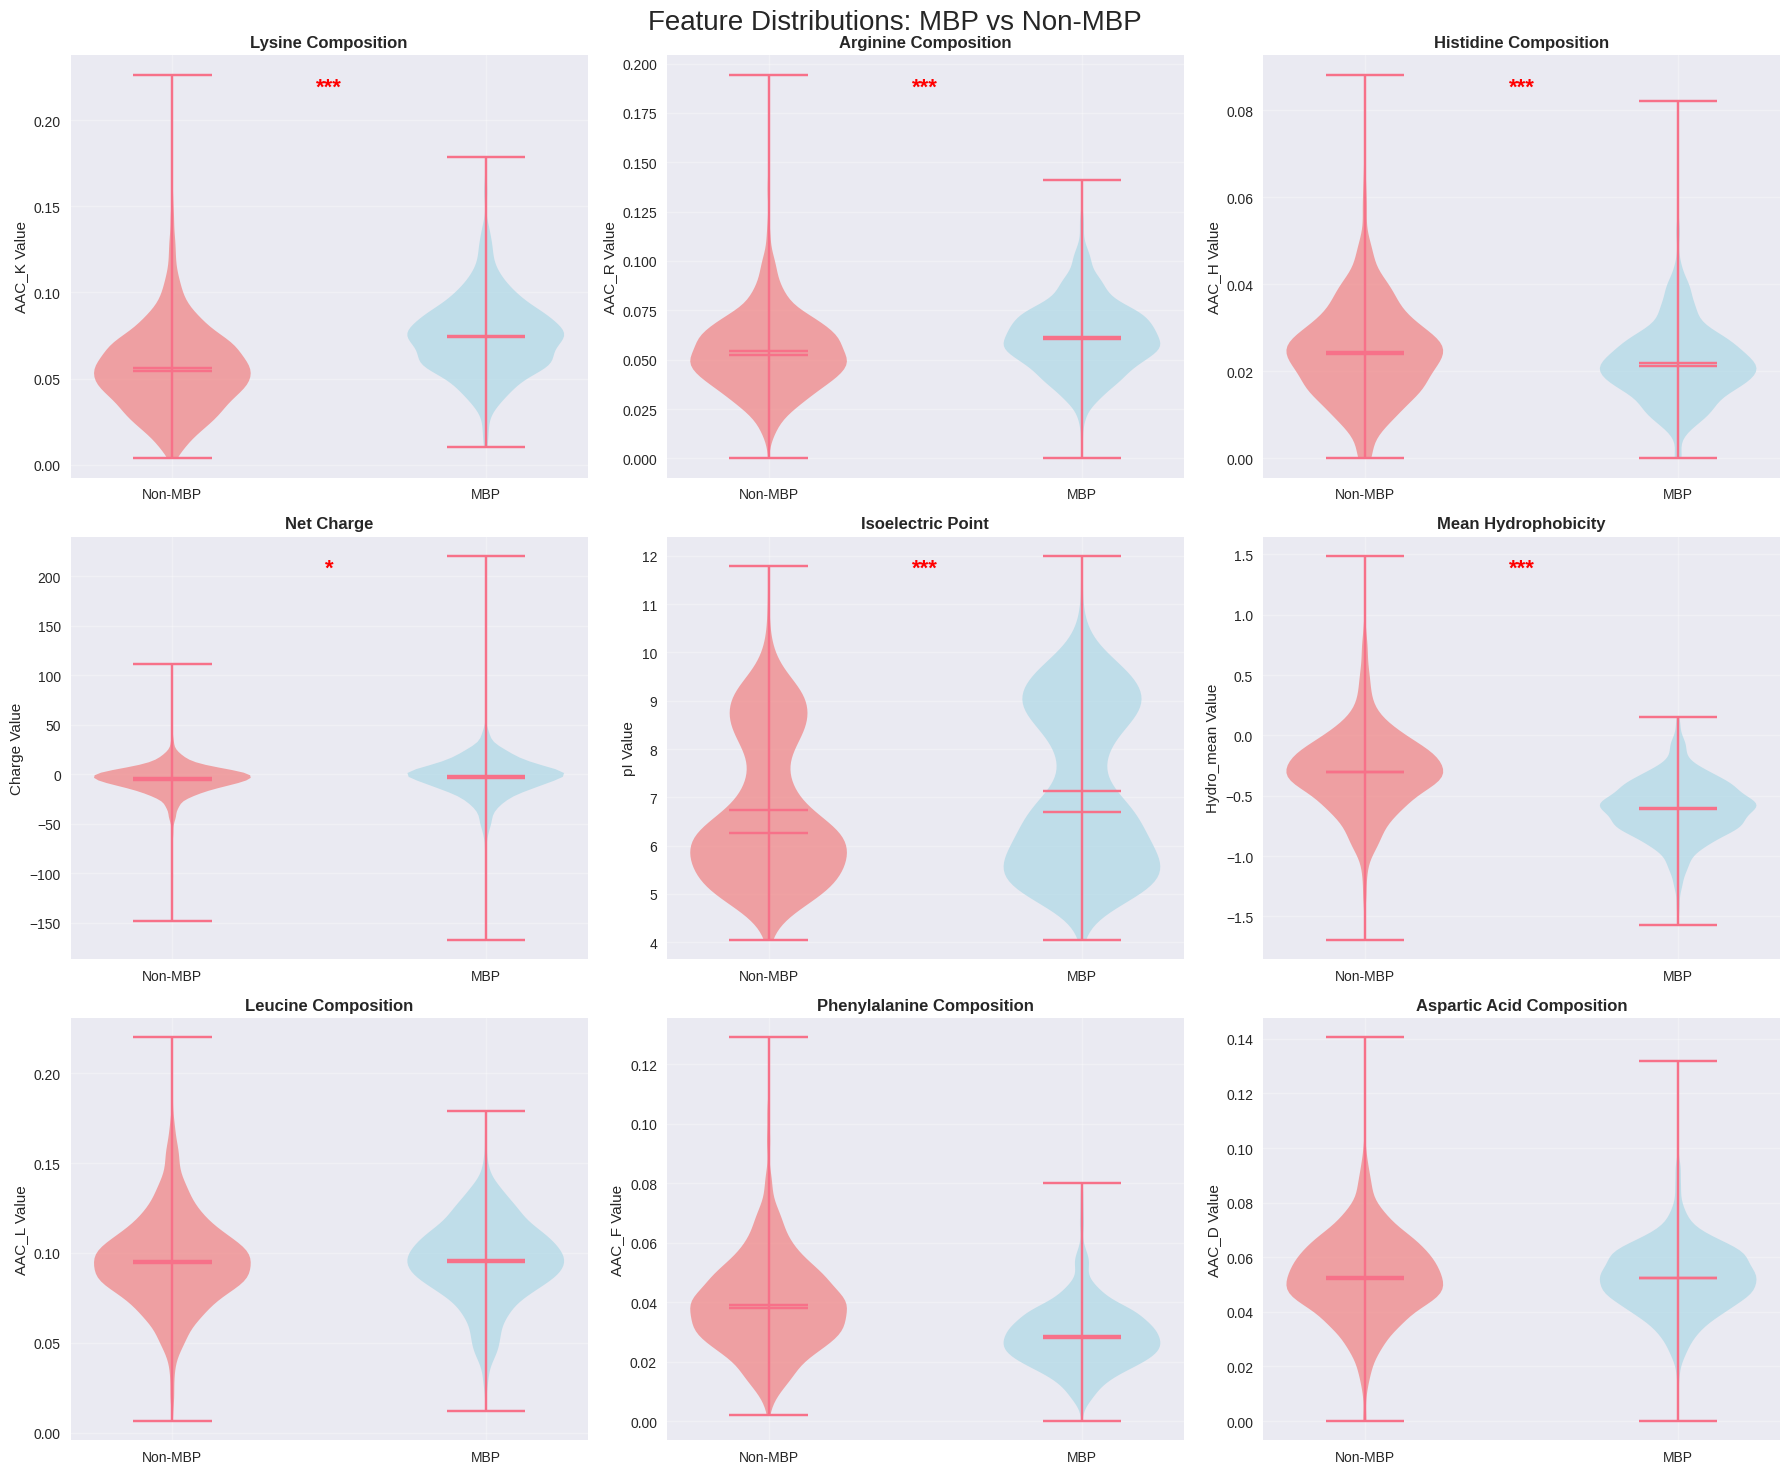


MOTIF PREVALENCE ANALYSIS


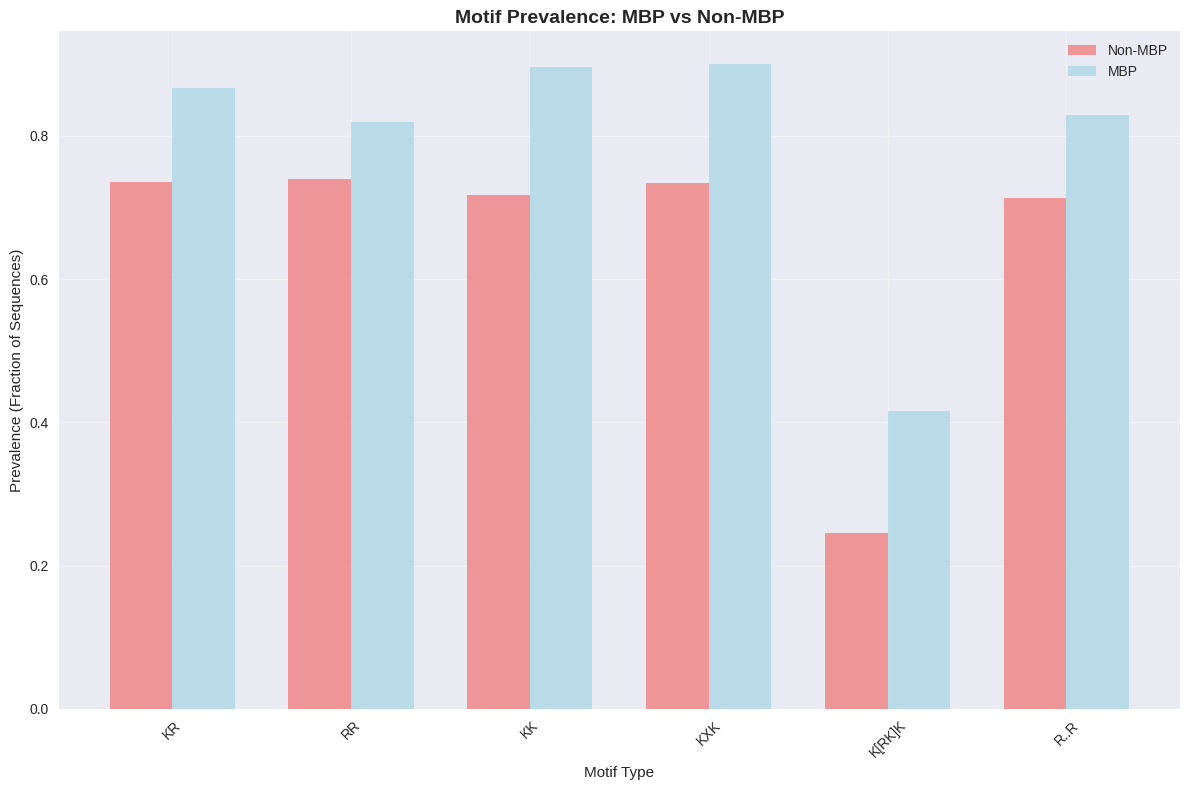

Motif prevalence comparison:
       Motif_KR  Motif_RR  Motif_KK  Motif_KXK  Motif_K[RK]K  Motif_R..R
Label                                                                   
0         0.735     0.740     0.717      0.734         0.246       0.713
1         0.867     0.819     0.896      0.901         0.416       0.828

HIGH-DIMENSIONAL EMBEDDING VISUALIZATION
Analyzing 1024 embedding dimensions...
Embedding matrix shape: (3072, 1024)

Performing PCA...
PCA explained variance ratio (first 10 components): [0.29083983 0.2392634  0.05800933 0.0399152  0.03168037 0.02028186
 0.01984019 0.01659179 0.01482694 0.01371655]
Cumulative variance explained by first 10 components: 0.745
Performing t-SNE...
Performing UMAP...


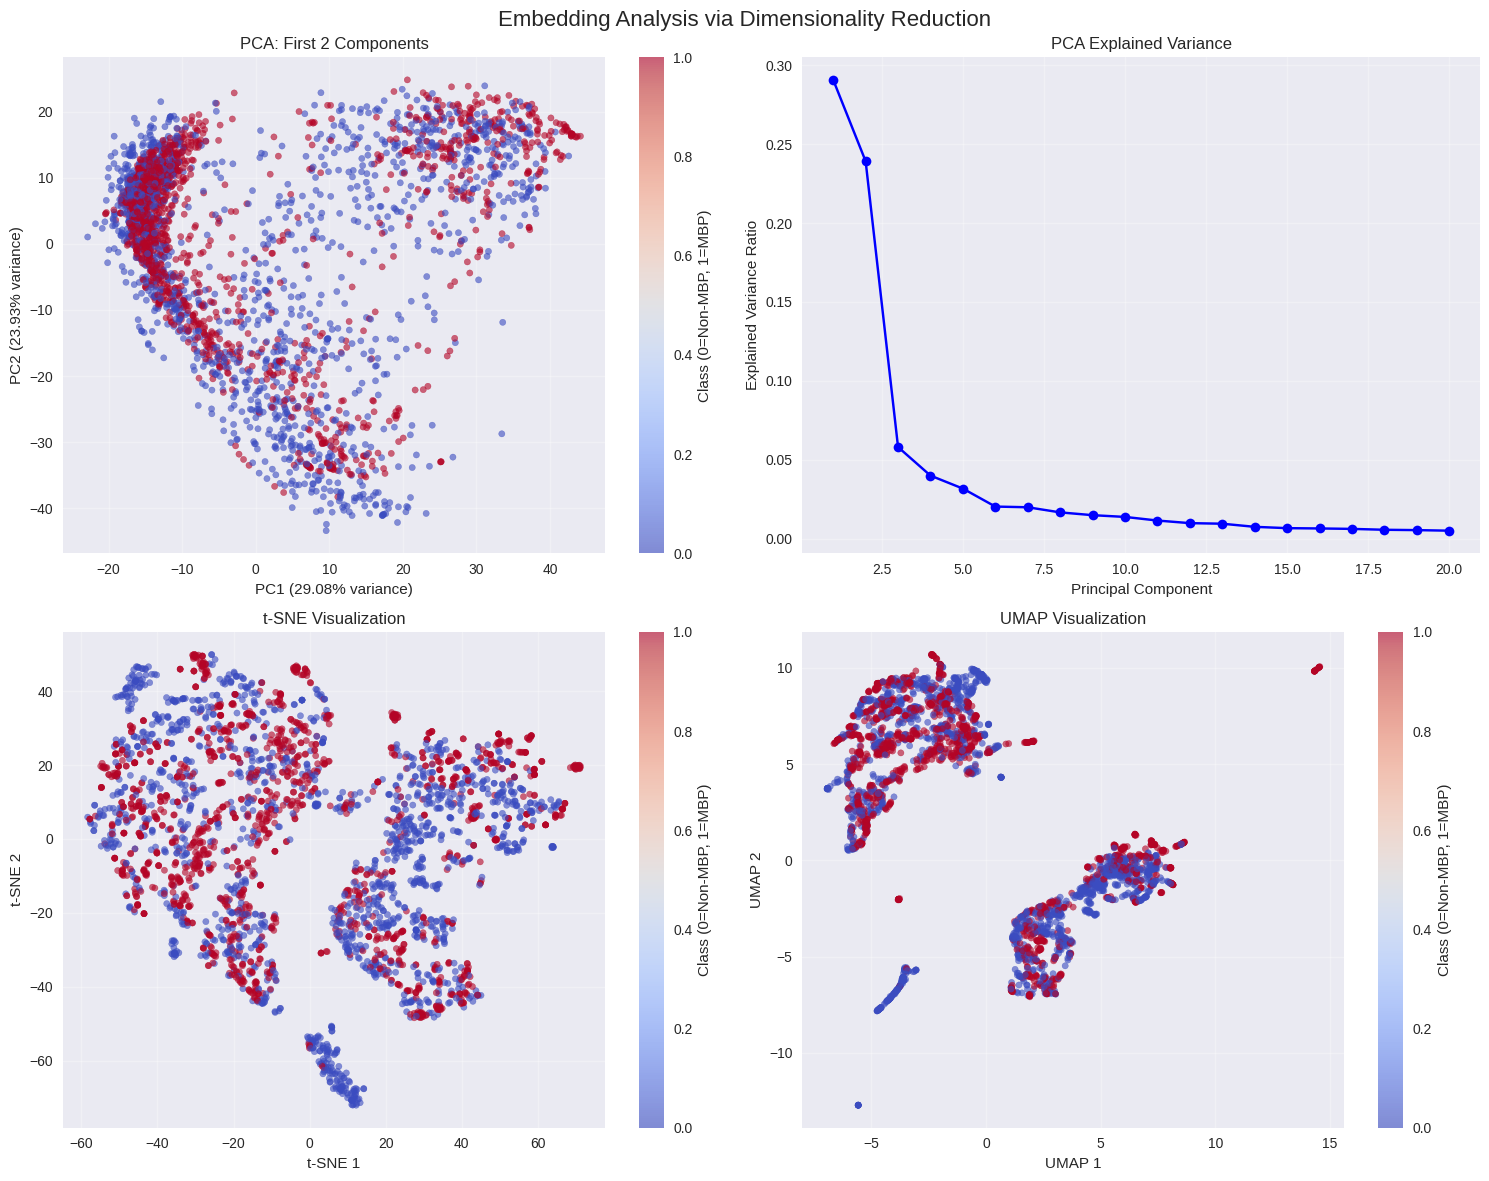


FEATURE CORRELATION ANALYSIS
Computing correlation matrix for 31 traditional features...

Highly correlated feature pairs (|correlation| > 0.7):
  Charge <-> pI: 0.747


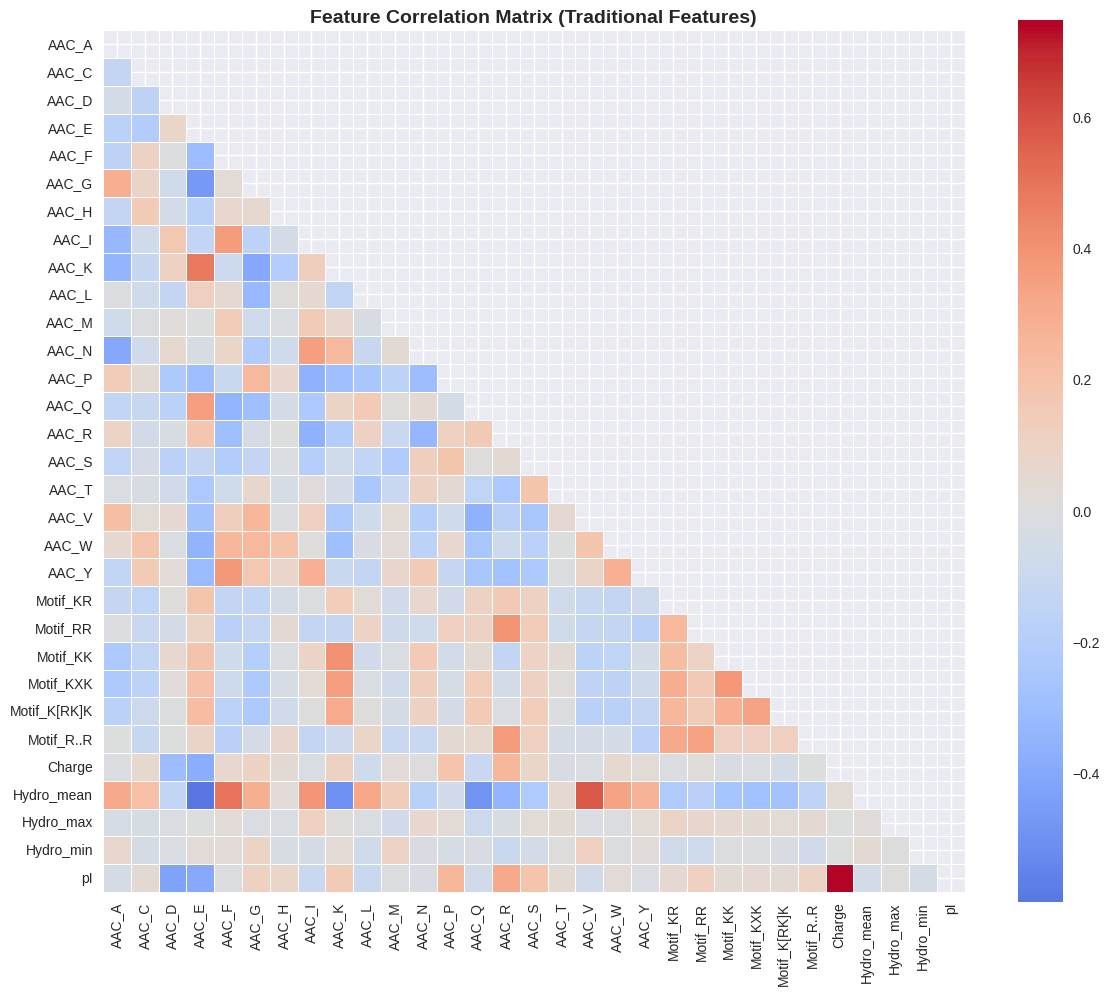

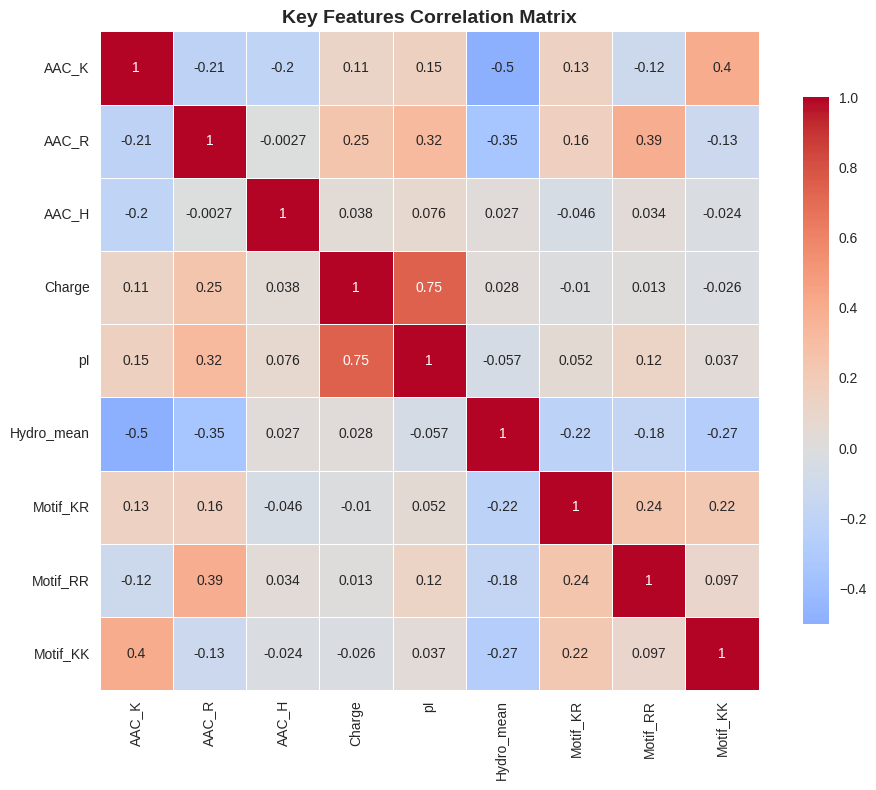


SUMMARY FOR PRESENTATION
KEY FINDINGS:
----------------------------------------
Most discriminative features (by t-statistic):
1. Hydro_mean: MBPs have lower values (p=0.0000)
2. AAC_K: MBPs have higher values (p=0.0000)
3. Motif_KK: MBPs have higher values (p=0.0000)
4. AAC_R: MBPs have higher values (p=0.0000)
5. Motif_KR: MBPs have higher values (p=0.0000)

Embedding analysis:
- Embedding dimensions: 1024
- PCA top 10 components explain 74.5% of variance
- Visual clustering observed in t-SNE and UMAP plots

Dataset summary:
- Total sequences: 3072
- MBP sequences: 1533 (49.9%)
- Non-MBP sequences: 1539 (50.1%)
- Total features extracted: 1055

RECOMMENDATIONS FOR PPT:
----------------------------------------
1. Show the violin plot for Lysine (AAC_K) or Net Charge - clear separation
2. Include t-SNE or UMAP plot showing MBP clustering
3. Show motif prevalence bar chart if motifs are discriminative
4. Mention top 3 most discriminative features from statistical analysis

Visualizatio

In [ ]:
# Feature Visualization and Analysis Notebook
# Analyzing extracted features from MBP dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Starting feature visualization and analysis...")

# =============================================================================
# 1. LOAD EXTRACTED FEATURES
# =============================================================================

print("\n" + "="*60)
print("LOADING EXTRACTED FEATURES")
print("="*60)

# Load the extracted features
df_features = pd.read_csv('data/features_cleaned_with_embeddings.csv')

print(f"Feature dataset shape: {df_features.shape}")
print(f"Columns: {len(df_features.columns)} total")

# Separate feature types
embedding_cols = [col for col in df_features.columns if col.startswith('E_')]
aac_cols = [col for col in df_features.columns if col.startswith('AAC_')]
motif_cols = [col for col in df_features.columns if col.startswith('Motif_')]
physicochemical_cols = ['Charge', 'Hydro_mean', 'Hydro_max', 'Hydro_min', 'pI']
metadata_cols = ['Label', 'Protein_ID']

# All traditional features (non-embedding)
traditional_cols = aac_cols + motif_cols + physicochemical_cols

print(f"\nFeature breakdown:")
print(f"  Embedding features: {len(embedding_cols)}")
print(f"  AAC features: {len(aac_cols)}")
print(f"  Motif features: {len(motif_cols)}")
print(f"  Physicochemical features: {len(physicochemical_cols)}")
print(f"  Traditional features total: {len(traditional_cols)}")

# Class distribution
print(f"\nClass distribution:")
class_counts = df_features['Label'].value_counts()
print(class_counts)
print(f"Balance ratio: {class_counts[1] / class_counts[0]:.3f}")

# =============================================================================
# 2. ANALYZE LOW-DIMENSIONAL / TRADITIONAL FEATURES
# =============================================================================

print("\n" + "="*60)
print("TRADITIONAL FEATURE ANALYSIS")
print("="*60)

# Statistical comparison between classes
def compare_classes(feature_name):
    """Compare feature values between MBP and non-MBP classes"""
    mbp_values = df_features[df_features['Label'] == 1][feature_name]
    non_mbp_values = df_features[df_features['Label'] == 0][feature_name]

    # T-test
    t_stat, p_value = ttest_ind(mbp_values, non_mbp_values)

    return {
        'feature': feature_name,
        'mbp_mean': mbp_values.mean(),
        'non_mbp_mean': non_mbp_values.mean(),
        'mbp_std': mbp_values.std(),
        'non_mbp_std': non_mbp_values.std(),
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Analyze key features
key_features = ['AAC_K', 'AAC_R', 'AAC_H', 'Charge', 'pI', 'Hydro_mean'] + motif_cols[:3]
comparison_results = []

print("Statistical comparison (MBP vs Non-MBP):")
print("-" * 80)
print(f"{'Feature':<15} {'MBP Mean':<10} {'Non-MBP Mean':<12} {'P-value':<10} {'Significant'}")
print("-" * 80)

for feature in key_features:
    if feature in df_features.columns:
        result = compare_classes(feature)
        comparison_results.append(result)
        sig_marker = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else ""
        print(f"{feature:<15} {result['mbp_mean']:<10.4f} {result['non_mbp_mean']:<12.4f} {result['p_value']:<10.4f} {sig_marker}")

# =============================================================================
# 3. VISUALIZATION 1: DISTRIBUTION PLOTS FOR KEY FEATURES
# =============================================================================

print("\n" + "="*60)
print("CREATING DISTRIBUTION PLOTS")
print("="*60)

# Create comprehensive distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Feature Distributions: MBP vs Non-MBP', fontsize=20, y=0.98)

# Define features to plot with descriptions
plot_features = [
    ('AAC_K', 'Lysine Composition'),
    ('AAC_R', 'Arginine Composition'),
    ('AAC_H', 'Histidine Composition'),
    ('Charge', 'Net Charge'),
    ('pI', 'Isoelectric Point'),
    ('Hydro_mean', 'Mean Hydrophobicity'),
    ('AAC_L', 'Leucine Composition'),
    ('AAC_F', 'Phenylalanine Composition'),
    ('AAC_D', 'Aspartic Acid Composition')
]

for idx, (feature, title) in enumerate(plot_features):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]

    if feature in df_features.columns:
        # Create violin plot
        data_to_plot = []
        labels_to_plot = []

        mbp_data = df_features[df_features['Label'] == 1][feature]
        non_mbp_data = df_features[df_features['Label'] == 0][feature]

        data_to_plot = [non_mbp_data, mbp_data]

        violin_parts = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)

        # Customize violin plot colors
        violin_parts['bodies'][0].set_facecolor('lightcoral')
        violin_parts['bodies'][0].set_alpha(0.7)
        violin_parts['bodies'][1].set_facecolor('lightblue')
        violin_parts['bodies'][1].set_alpha(0.7)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Non-MBP', 'MBP'])
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{feature} Value')
        ax.grid(True, alpha=0.3)

        # Add statistical annotation
        result = next((r for r in comparison_results if r['feature'] == feature), None)
        if result and result['significant']:
            sig_text = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*"
            ax.text(0.5, 0.95, sig_text, transform=ax.transAxes, ha='center', va='top',
                   fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. MOTIF ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("MOTIF PREVALENCE ANALYSIS")
print("="*60)

if motif_cols:
    # Calculate motif prevalence by class
    motif_prevalence = df_features.groupby('Label')[motif_cols].mean()

    # Create motif comparison plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    x = np.arange(len(motif_cols))
    width = 0.35

    non_mbp_prev = motif_prevalence.loc[0, motif_cols]
    mbp_prev = motif_prevalence.loc[1, motif_cols]

    ax.bar(x - width/2, non_mbp_prev, width, label='Non-MBP', alpha=0.8, color='lightcoral')
    ax.bar(x + width/2, mbp_prev, width, label='MBP', alpha=0.8, color='lightblue')

    ax.set_xlabel('Motif Type')
    ax.set_ylabel('Prevalence (Fraction of Sequences)')
    ax.set_title('Motif Prevalence: MBP vs Non-MBP', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([col.replace('Motif_', '') for col in motif_cols], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Motif prevalence comparison:")
    print(motif_prevalence.round(3))

# =============================================================================
# 5. HIGH-DIMENSIONAL EMBEDDING VISUALIZATION
# =============================================================================

print("\n" + "="*60)
print("HIGH-DIMENSIONAL EMBEDDING VISUALIZATION")
print("="*60)

if embedding_cols:
    print(f"Analyzing {len(embedding_cols)} embedding dimensions...")

    # Extract embeddings and labels
    X_embeddings = df_features[embedding_cols].values
    y_labels = df_features['Label'].values

    # Standardize embeddings
    scaler = StandardScaler()
    X_embeddings_scaled = scaler.fit_transform(X_embeddings)

    print(f"Embedding matrix shape: {X_embeddings_scaled.shape}")

    # =============================================================================
    # 5.1. PCA VISUALIZATION
    # =============================================================================

    print("\nPerforming PCA...")
    pca = PCA(n_components=50)  # Keep top 50 components for analysis
    X_pca = pca.fit_transform(X_embeddings_scaled)

    print(f"PCA explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")
    print(f"Cumulative variance explained by first 10 components: {pca.explained_variance_ratio_[:10].sum():.3f}")

    # Plot PCA results
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Embedding Analysis via Dimensionality Reduction', fontsize=16)

    # PCA 2D
    ax1 = axes[0, 0]
    scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.set_title('PCA: First 2 Components')
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Class (0=Non-MBP, 1=MBP)')

    # Explained variance plot
    ax2 = axes[0, 1]
    ax2.plot(range(1, 21), pca.explained_variance_ratio_[:20], 'bo-')
    ax2.set_xlabel('Principal Component')
    ax2.set_ylabel('Explained Variance Ratio')
    ax2.set_title('PCA Explained Variance')
    ax2.grid(True, alpha=0.3)

    # =============================================================================
    # 5.2. t-SNE VISUALIZATION
    # =============================================================================

    print("Performing t-SNE...")
    # Use PCA-reduced data for t-SNE (faster and often better results)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_pca[:, :30])  # Use first 30 PCA components

    ax3 = axes[1, 0]
    scatter = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax3.set_xlabel('t-SNE 1')
    ax3.set_ylabel('t-SNE 2')
    ax3.set_title('t-SNE Visualization')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Class (0=Non-MBP, 1=MBP)')

    # =============================================================================
    # 5.3. UMAP VISUALIZATION
    # =============================================================================

    print("Performing UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_pca[:, :30])

    ax4 = axes[1, 1]
    scatter = ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, s=20)
    ax4.set_xlabel('UMAP 1')
    ax4.set_ylabel('UMAP 2')
    ax4.set_title('UMAP Visualization')
    ax4.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax4, label='Class (0=Non-MBP, 1=MBP)')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 6. FEATURE CORRELATION ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Correlation analysis for traditional features
traditional_features_df = df_features[traditional_cols]

print(f"Computing correlation matrix for {len(traditional_cols)} traditional features...")

# Compute correlation matrix
correlation_matrix = traditional_features_df.corr()

# Find highly correlated feature pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = abs(corr_matrix.iloc[i, j])
            if corr_val > threshold:
                high_corr_pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    return high_corr_pairs

high_corr_pairs = find_high_correlations(correlation_matrix, 0.7)

print(f"\nHighly correlated feature pairs (|correlation| > 0.7):")
for pair in high_corr_pairs[:10]:  # Show top 10
    print(f"  {pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.3f}")

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Traditional Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Focus on most important features correlation
important_features = ['AAC_K', 'AAC_R', 'AAC_H', 'Charge', 'pI', 'Hydro_mean'] + motif_cols[:3]
important_features = [f for f in important_features if f in traditional_features_df.columns]

if len(important_features) > 3:
    plt.figure(figsize=(10, 8))
    important_corr = traditional_features_df[important_features].corr()
    sns.heatmap(important_corr, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Key Features Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =============================================================================
# 7. SUMMARY STATISTICS FOR PRESENTATION
# =============================================================================

print("\n" + "="*60)
print("SUMMARY FOR PRESENTATION")
print("="*60)

print("KEY FINDINGS:")
print("-" * 40)

# Most discriminative features
discriminative_features = sorted(comparison_results, key=lambda x: abs(x['t_statistic']), reverse=True)

print("Most discriminative features (by t-statistic):")
for i, result in enumerate(discriminative_features[:5]):
    direction = "higher" if result['mbp_mean'] > result['non_mbp_mean'] else "lower"
    print(f"{i+1}. {result['feature']}: MBPs have {direction} values (p={result['p_value']:.4f})")

# Embedding clustering quality
if embedding_cols:
    print(f"\nEmbedding analysis:")
    print(f"- Embedding dimensions: {len(embedding_cols)}")
    print(f"- PCA top 10 components explain {pca.explained_variance_ratio_[:10].sum():.1%} of variance")
    print(f"- Visual clustering observed in t-SNE and UMAP plots")

print(f"\nDataset summary:")
print(f"- Total sequences: {len(df_features)}")
print(f"- MBP sequences: {class_counts[1]} ({class_counts[1]/len(df_features)*100:.1f}%)")
print(f"- Non-MBP sequences: {class_counts[0]} ({class_counts[0]/len(df_features)*100:.1f}%)")
print(f"- Total features extracted: {len(traditional_cols) + len(embedding_cols)}")

print("\nRECOMMENDATIONS FOR PPT:")
print("-" * 40)
print("1. Show the violin plot for Lysine (AAC_K) or Net Charge - clear separation")
print("2. Include t-SNE or UMAP plot showing MBP clustering")
print("3. Show motif prevalence bar chart if motifs are discriminative")
print("4. Mention top 3 most discriminative features from statistical analysis")

print("\nVisualization complete! All plots generated for analysis.")

In [6]:
# ============================================================================
# COMPLETE DEBUG SCRIPT - Standalone
# ============================================================================

import pandas as pd
import numpy as np
import joblib
import sys
import os

# Setup paths
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')
sys.path.append('/content/drive/MyDrive/MBP_PREDICTOR')

# Import feature extraction modules
from src.feature_aac import compute_aac
from src.feature_charge import compute_charge
from src.feature_hydrophobicity import compute_hydrophobicity
from src.feature_pi import compute_pi
from src.feature_motif import compute_motif
from src.feature_embeddings import ProteinEmbedder

print("✅ Modules imported")

# Load models
print("\nLoading models...")
model_92 = joblib.load('TRAINED_MODELS/LightGBM_92.pkl')
model_91 = joblib.load('TRAINED_MODELS/LightGBM_91.22.pkl')
print(f"✅ Models loaded")
print(f"   Model 92% expects {model_92.n_features_} features")
print(f"   Model 91.22% expects {model_91.n_features_} features")

# Initialize embedder
print("\nInitializing embedder...")
embedder = ProteinEmbedder()
print("✅ Embedder loaded")

# Define feature extraction function
def extract_features(sequence):
    """Extract all features from a protein sequence"""
    try:
        features = {}

        # AAC features (20)
        features.update(compute_aac(sequence))

        # Charge feature (1)
        features.update(compute_charge(sequence))

        # Hydrophobicity features (3)
        features.update(compute_hydrophobicity(sequence))

        # pI feature (1)
        pi_value = compute_pi(sequence)
        features["pI"] = float(pi_value) if pi_value is not None else 7.0

        # Motif features (6)
        features.update(compute_motif(sequence))

        # Embeddings (1024)
        if embedder is not None:
            try:
                embedding_vector = embedder.get_embedding(sequence)
                embedding_features = {f"E_{i}": float(val) for i, val in enumerate(embedding_vector)}
                features.update(embedding_features)
            except Exception as e:
                print(f"Warning: Embedding failed, using zeros: {e}")
                embedding_features = {f"E_{i}": 0.0 for i in range(1024)}
                features.update(embedding_features)
        else:
            embedding_features = {f"E_{i}": 0.0 for i in range(1024)}
            features.update(embedding_features)

        return features

    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

# ============================================================================
# START DEBUGGING
# ============================================================================

print("\n" + "="*60)
print("DEBUGGING PREDICTION PIPELINE")
print("="*60)

# Test with a known sequence
test_sequence = "KRIVQRIKDFLRNLVPRTES"  # Simple test sequence
print(f"\nTest Sequence: {test_sequence}")
print(f"Length: {len(test_sequence)}")

# Extract features
print("\n" + "="*60)
print("EXTRACTING FEATURES")
print("="*60)

features = extract_features(test_sequence)

if features:
    print(f"✅ Features extracted successfully")
    print(f"   Total features: {len(features)}")

    # Check feature breakdown
    aac_count = len([k for k in features.keys() if k.startswith('AAC_')])
    charge_count = len([k for k in features.keys() if 'Charge' in k])
    hydro_count = len([k for k in features.keys() if k.startswith('Hydro_')])
    pi_count = len([k for k in features.keys() if k == 'pI'])
    motif_count = len([k for k in features.keys() if k.startswith('Motif_')])
    embed_count = len([k for k in features.keys() if k.startswith('E_')])

    print(f"\n   Feature breakdown:")
    print(f"   - AAC: {aac_count}, Charge: {charge_count}, Hydro: {hydro_count}")
    print(f"   - pI: {pi_count}, Motif: {motif_count}, Embeddings: {embed_count}")
    print(f"   - Total: {aac_count + charge_count + hydro_count + pi_count + motif_count + embed_count}")

    # Sample values
    print("\n   Sample feature values:")
    for i, (key, val) in enumerate(list(features.items())[:5]):
        print(f"   {key}: {val}")
else:
    print("❌ Feature extraction failed!")
    exit()

# Convert to DataFrame
print("\n" + "="*60)
print("PREPARING FOR PREDICTION")
print("="*60)

feature_df = pd.DataFrame([features])
print(f"DataFrame shape: {feature_df.shape}")
print(f"Columns: {list(feature_df.columns[:10])}...")

# Check data types
non_numeric = [col for col in feature_df.columns if not pd.api.types.is_numeric_dtype(feature_df[col])]
if non_numeric:
    print(f"\n❌ Non-numeric columns found: {non_numeric}")
else:
    print(f"✅ All columns are numeric")

# Check missing values
missing = feature_df.isnull().sum().sum()
if missing > 0:
    print(f"❌ Missing values: {missing}")
else:
    print(f"✅ No missing values")

# Load training data to compare feature order
print("\n" + "="*60)
print("CHECKING FEATURE ORDER")
print("="*60)

try:
    training_features = pd.read_csv("data/features_cleaned_final.csv")
    training_feature_cols = [col for col in training_features.columns
                            if col not in ['Label', 'Protein_ID']]

    print(f"Training features: {len(training_feature_cols)}")
    print(f"Current features: {len(feature_df.columns)}")

    # Compare
    current_cols = list(feature_df.columns)
    missing = set(training_feature_cols) - set(current_cols)
    extra = set(current_cols) - set(training_feature_cols)

    if missing:
        print(f"\n❌ Missing in current: {list(missing)[:5]}")
    if extra:
        print(f"\n❌ Extra in current: {list(extra)[:5]}")

    if not missing and not extra:
        print("✅ Feature names match!")

        # Reorder to match training
        if current_cols != training_feature_cols:
            print("⚠️  Reordering features to match training...")
            feature_df = feature_df[training_feature_cols]
            print("✅ Features reordered")
        else:
            print("✅ Feature order matches!")

except Exception as e:
    print(f"⚠️  Could not load training data: {e}")

# Make predictions
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)

print("\nModel 92%:")
try:
    prediction_92 = model_92.predict(feature_df)[0]
    probability_92 = model_92.predict_proba(feature_df)[0]

    print(f"   Prediction: {prediction_92} ({'MBP' if prediction_92 == 1 else 'Non-MBP'})")
    print(f"   Probabilities: [Non-MBP: {probability_92[0]:.4f}, MBP: {probability_92[1]:.4f}]")
    print(f"   Confidence: {max(probability_92)*100:.2f}%")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\nModel 91.22%:")
try:
    prediction_91 = model_91.predict(feature_df)[0]
    probability_91 = model_91.predict_proba(feature_df)[0]

    print(f"   Prediction: {prediction_91} ({'MBP' if prediction_91 == 1 else 'Non-MBP'})")
    print(f"   Probabilities: [Non-MBP: {probability_91[0]:.4f}, MBP: {probability_91[1]:.4f}]")
    print(f"   Confidence: {max(probability_91)*100:.2f}%")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Test with known training samples
print("\n" + "="*60)
print("VALIDATION WITH TRAINING DATA")
print("="*60)

try:
    training_data = pd.read_csv("data/features_cleaned_final.csv")

    # Test one MBP and one Non-MBP
    mbp_sample = training_data[training_data['Label'] == 1].iloc[0]
    non_mbp_sample = training_data[training_data['Label'] == 0].iloc[0]

    for name, sample in [("MBP", mbp_sample), ("Non-MBP", non_mbp_sample)]:
        print(f"\nKnown {name} sample (ID: {sample['Protein_ID']}):")

        sample_features = sample.drop(['Label', 'Protein_ID']).values.reshape(1, -1)
        feature_cols = [col for col in training_data.columns if col not in ['Label', 'Protein_ID']]
        sample_df = pd.DataFrame(sample_features, columns=feature_cols)

        pred = model_92.predict(sample_df)[0]
        prob = model_92.predict_proba(sample_df)[0]

        actual = int(sample['Label'])
        correct = "✅ CORRECT" if pred == actual else "❌ WRONG"

        print(f"   Actual: {actual} ({name})")
        print(f"   Predicted: {pred} ({'MBP' if pred == 1 else 'Non-MBP'})")
        print(f"   Probabilities: [Non-MBP: {prob[0]:.4f}, MBP: {prob[1]:.4f}]")
        print(f"   {correct}")

except Exception as e:
    print(f"Could not validate: {e}")

print("\n" + "="*60)
print("DEBUG COMPLETE")
print("="*60)
print("\nIf predictions look wrong, check:")
print("1. Are training samples predicted correctly? (see above)")
print("2. Is feature order matching training data?")
print("3. Are all 1055 features present?")
print("4. Are embeddings computed correctly?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modules imported

Loading models...
✅ Models loaded
   Model 92% expects 1055 features
   Model 91.22% expects 1055 features

Initializing embedder...
Loading model Rostlab/prot_bert on cuda...
✅ Embedder loaded

DEBUGGING PREDICTION PIPELINE

Test Sequence: KRIVQRIKDFLRNLVPRTES
Length: 20

EXTRACTING FEATURES
✅ Features extracted successfully
   Total features: 1055

   Feature breakdown:
   - AAC: 20, Charge: 1, Hydro: 3
   - pI: 1, Motif: 6, Embeddings: 1024
   - Total: 1055

   Sample feature values:
   AAC_A: 0.0
   AAC_C: 0.0
   AAC_D: 0.05
   AAC_E: 0.05
   AAC_F: 0.05

PREPARING FOR PREDICTION
DataFrame shape: (1, 1055)
Columns: ['AAC_A', 'AAC_C', 'AAC_D', 'AAC_E', 'AAC_F', 'AAC_G', 'AAC_H', 'AAC_I', 'AAC_K', 'AAC_L']...
✅ All columns are numeric
✅ No missing values

CHECKING FEATURE ORDER
Training features: 1055
Current features: 1055
✅ Feature nam

In [13]:
# ============================================================================
# DIAGNOSE SPECIFIC SEQUENCE PREDICTION ERROR
# ============================================================================

import pandas as pd
import numpy as np
import joblib
import sys
import os
from google.colab import drive

# Setup
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')
sys.path.append('/content/drive/MyDrive/MBP_PREDICTOR')

from src.feature_aac import compute_aac
from src.feature_charge import compute_charge
from src.feature_hydrophobicity import compute_hydrophobicity
from src.feature_pi import compute_pi
from src.feature_motif import compute_motif
from src.feature_embeddings import ProteinEmbedder

print("="*60)
print("DIAGNOSING SPECIFIC MBP SEQUENCE PREDICTION ERROR")
print("="*60)

# The problematic sequence (known MBP)
test_sequence = "MSDVSADGGFLSAEQATTPVAIPTPYPSLTVSASYKEKSSGRRRPVRPSFDAAADNEFITLLHGSDPVKVELNRLENEVRDKDRELSEANAEIKALRLSERQREKACEELTDELAKLDGKLKLTESLLQSKNLEIKKINEEKKASMAAQFAAEATLRRVHAAQKDDDMPPIEAILAPLEAELKLARSEIGKLQEDNRALDRLTKSKEAALLDAERTVETALAKAALVDDLQNKNQELMKQIEICQEENKILDRMHRQKVAEVEKLTQTVRELEEAVLAGGAAANAVRDYQRKFQEMNEERKTLDRELARAKVTANRVATVVANEWKDGNDKVMPVKQWLEERRFLQGEMQQLRDKLAISDRAAKSEAQLKDKFQLRLRVLEETLRGTSSISIRNTPEGRSMSNGPSRRQSIGGSDNLQKFASNGFLSKKTPMRNSFTSNSTSVLKNAKGTSKSFDGGTRSLDRGKALLKGPGNYSFNKACDETKESESPNTWKEDSEEKPPSELPAPATEDNVPGVLYDLLQKEVVALRKSSHEKDQSLKDKDDAIEMLAKKVETLTKAMEVEAKKMRREVAAMEKEVAAMRVDKDQDNRAKRSSNTKPSSNTAQILAARAAGRSGLTRSTQ"


print(f"\nSequence: {test_sequence[:80]}...")
print(f"Length: {len(test_sequence)} amino acids")
print(f"Known label: MBP ( Microtubule-Binding Protein)")

# Load models
model_92 = joblib.load('TRAINED_MODELS/LightGBM_92.pkl')
model_91 = joblib.load('TRAINED_MODELS/LightGBM_91.22.pkl')

# Initialize embedder
print("\nInitializing embedder...")
embedder = ProteinEmbedder()

# Extract features
def extract_features(sequence):
    features = {}
    features.update(compute_aac(sequence))
    features.update(compute_charge(sequence))
    features.update(compute_hydrophobicity(sequence))
    pi_value = compute_pi(sequence)
    features["pI"] = float(pi_value) if pi_value is not None else 7.0
    features.update(compute_motif(sequence))

    if embedder is not None:
        try:
            embedding_vector = embedder.get_embedding(sequence)
            embedding_features = {f"E_{i}": float(val) for i, val in enumerate(embedding_vector)}
            features.update(embedding_features)
        except Exception as e:
            print(f"Embedding failed: {e}")
            embedding_features = {f"E_{i}": 0.0 for i in range(1024)}
            features.update(embedding_features)

    return features

print("Extracting features...")
features = extract_features(test_sequence)
print(f"Features extracted: {len(features)}")

# Look at key MBP-related features
print("\n" + "="*60)
print("KEY MBP-RELATED FEATURES")
print("="*60)

print(f"\nAmino Acid Composition:")
print(f"  Lysine (K): {features['AAC_K']:.4f}")
print(f"  Arginine (R): {features['AAC_R']:.4f}")
print(f"  Proline (P): {features['AAC_P']:.4f}")
print(f"  Glycine (G): {features['AAC_G']:.4f}")

print(f"\nBiochemical properties:")
print(f"  Net Charge: {features['Charge']:.4f}")
print(f"  pI: {features['pI']:.4f}")
print(f"  Hydrophobicity (mean): {features['Hydro_mean']:.4f}")

print(f"\nMotifs:")
for key in ['Motif_KR', 'Motif_RR', 'Motif_KK', 'Motif_KXK', 'Motif_K[RK]K', 'Motif_R..R']:
    print(f"  {key}: {features[key]}")

# Convert to DataFrame
feature_df = pd.DataFrame([features])

# Make predictions
print("\n" + "="*60)
print("PREDICTIONS")
print("="*60)

print("\nModel 92%:")
pred_92 = model_92.predict(feature_df)[0]
prob_92 = model_92.predict_proba(feature_df)[0]
print(f"  Prediction: {pred_92} ({'MBP' if pred_92 == 1 else 'Non-MBP'})")
print(f"  Probabilities: [Non-MBP: {prob_92[0]:.4f}, MBP: {prob_92[1]:.4f}]")
print(f"  Result: {'✅ CORRECT' if pred_92 == 1 else '❌ WRONG'}")

print("\nModel 91.22%:")
pred_91 = model_91.predict(feature_df)[0]
prob_91 = model_91.predict_proba(feature_df)[0]
print(f"  Prediction: {pred_91} ({'MBP' if pred_91 == 1 else 'Non-MBP'})")
print(f"  Probabilities: [Non-MBP: {prob_91[0]:.4f}, MBP: {prob_91[1]:.4f}]")
print(f"  Result: {'✅ CORRECT' if pred_91 == 1 else '❌ WRONG'}")

# Compare with similar sequences from training data
print("\n" + "="*60)
print("COMPARING WITH TRAINING DATA")
print("="*60)

# Check if this exact sequence is in training data
print("\nChecking if this sequence was in training...")
try:
    original_data = pd.read_csv("data/mbp_dataset_cleaned.csv")

    # Check if sequence exists
    matching = original_data[original_data['Sequence'] == test_sequence]

    if len(matching) > 0:
        print(f"⚠️  THIS SEQUENCE WAS IN TRAINING DATA!")
        print(f"  Protein ID: {matching.iloc[0]['Protein_ID']}")
        print(f"  Label: {matching.iloc[0]['Label']}")
        print(f"  This should be predicted correctly!")
    else:
        print("✅ This is a new sequence (not in training data)")

except Exception as e:
    print(f"Could not check training data: {e}")

# Look at feature importance if available
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

try:
    if hasattr(model_92, 'feature_importances_'):
        importances = model_92.feature_importances_
        feature_names = model_92.feature_name_ if hasattr(model_92, 'feature_name_') else list(features.keys())

        # Get top 10 most important features
        top_indices = np.argsort(importances)[-10:][::-1]

        print("\nTop 10 most important features for prediction:")
        for idx in top_indices:
            feat_name = feature_names[idx]
            importance = importances[idx]
            feat_value = features[feat_name]
            print(f"  {feat_name}: importance={importance:.4f}, value={feat_value:.4f}")
    else:
        print("Feature importance not available")

except Exception as e:
    print(f"Could not analyze feature importance: {e}")

# Summary
print("\n" + "="*60)
print("DIAGNOSIS")
print("="*60)

if pred_92 == 0 and pred_91 == 0:
    print("\n❌ BOTH MODELS FAILED")
    print("This indicates a systematic issue:")
    print("  1. The sequence characteristics differ significantly from training MBPs")
    print("  2. The embeddings may not be capturing MBP-specific patterns")
    print("  3. This could be a challenging edge case for the model")
    print("  4. Or there's a feature extraction inconsistency")
elif pred_92 == 0 or pred_91 == 0:
    print("\n⚠️  ONE MODEL FAILED")
    print("This suggests the sequence is borderline or ambiguous")
else:
    print("\n✅ BOTH MODELS CORRECT")

print("\nPossible causes of error:")
print("  1. Model hasn't learned this type of MBP pattern well")
print("  2. Sequence length ({} aa) may be unusual".format(len(test_sequence)))
print("  3. Training data may not have enough similar examples")
print("  4. Feature extraction may differ from training time")
print("  5. This protein may have weak MBP characteristics")

print("\nRecommendation:")
print("  Test with more known MBP sequences to see if this is:")
print("  - A systematic problem (all MBPs predicted wrong)")
print("  - A specific edge case (only some MBPs predicted wrong)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DIAGNOSING SPECIFIC MBP SEQUENCE PREDICTION ERROR

Sequence: MSDVSADGGFLSAEQATTPVAIPTPYPSLTVSASYKEKSSGRRRPVRPSFDAAADNEFITLLHGSDPVKVELNRLENEVR...
Length: 622 amino acids
Known label: MBP ( Microtubule-Binding Protein)

Initializing embedder...
Loading model Rostlab/prot_bert on cuda...
Extracting features...
Features extracted: 1055

KEY MBP-RELATED FEATURES

Amino Acid Composition:
  Lysine (K): 0.0981
  Arginine (R): 0.0772
  Proline (P): 0.0354
  Glycine (G): 0.0402

Biochemical properties:
  Net Charge: 5.2667
  pI: 8.6829
  Hydrophobicity (mean): -0.8072

Motifs:
  Motif_KR: 1
  Motif_RR: 1
  Motif_KK: 1
  Motif_KXK: 1
  Motif_K[RK]K: 0
  Motif_R..R: 1

PREDICTIONS

Model 92%:
  Prediction: 1 (MBP)
  Probabilities: [Non-MBP: 0.0000, MBP: 1.0000]
  Result: ✅ CORRECT

Model 91.22%:
  Prediction: 1 (MBP)
  Probabilities: [Non-MBP: 0.0000, MBP: 1.0000]
  Resu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VERIFYING TRAINING DATA QUALITY

Dataset Overview:
Total sequences: 3200
Columns: ['Protein_ID', 'Sequence', 'Label']

Class Distribution:
Label
1    1600
0    1600
Name: count, dtype: int64
MBP (1): 1600
Non-MBP (0): 1600
Balance ratio: 1.000

ANALYZING MICROTUBULE-BINDING PROTEIN CHARACTERISTICS

Calculating biochemical properties for all sequences...


/usr/local/lib/python3.12/dist-packages/Bio/SeqUtils/ProtParam.py:106: BiopythonDeprecationWarning: The get_amino_acids_percent method has been deprecated and will likely be removed from Biopython in the near future. Please use the amino_acids_percent attribute instead.
  warnings.warn(


  Processed 500/3200...
  Processed 1000/3200...
  Processed 1500/3200...
  Processed 2000/3200...
  Processed 2500/3200...
  Processed 3000/3200...
Successfully analyzed: 3190
Failed: 10

COMPARISON: MBP vs NON-MBP

Property             MBP Mean        Non-MBP Mean    Difference     
-----------------------------------------------------------------
Length               797.8839        682.2701        115.6139       
Lysine               0.0749          0.0562          0.0186         
Arginine             0.0612          0.0541          0.0072         
Pos_Charge           0.1581          0.1347          0.0233         
Net_Charge           0.0185          0.0153          0.0032         
pI                   7.1196          6.7129          0.4066         
Hydrophobicity       -0.6112         -0.3073         -0.3038        
Proline              0.0495          0.0543          -0.0048        
Glycine              0.0546          0.0683          -0.0137        

EXPECTED vs OBSERVED CHARA

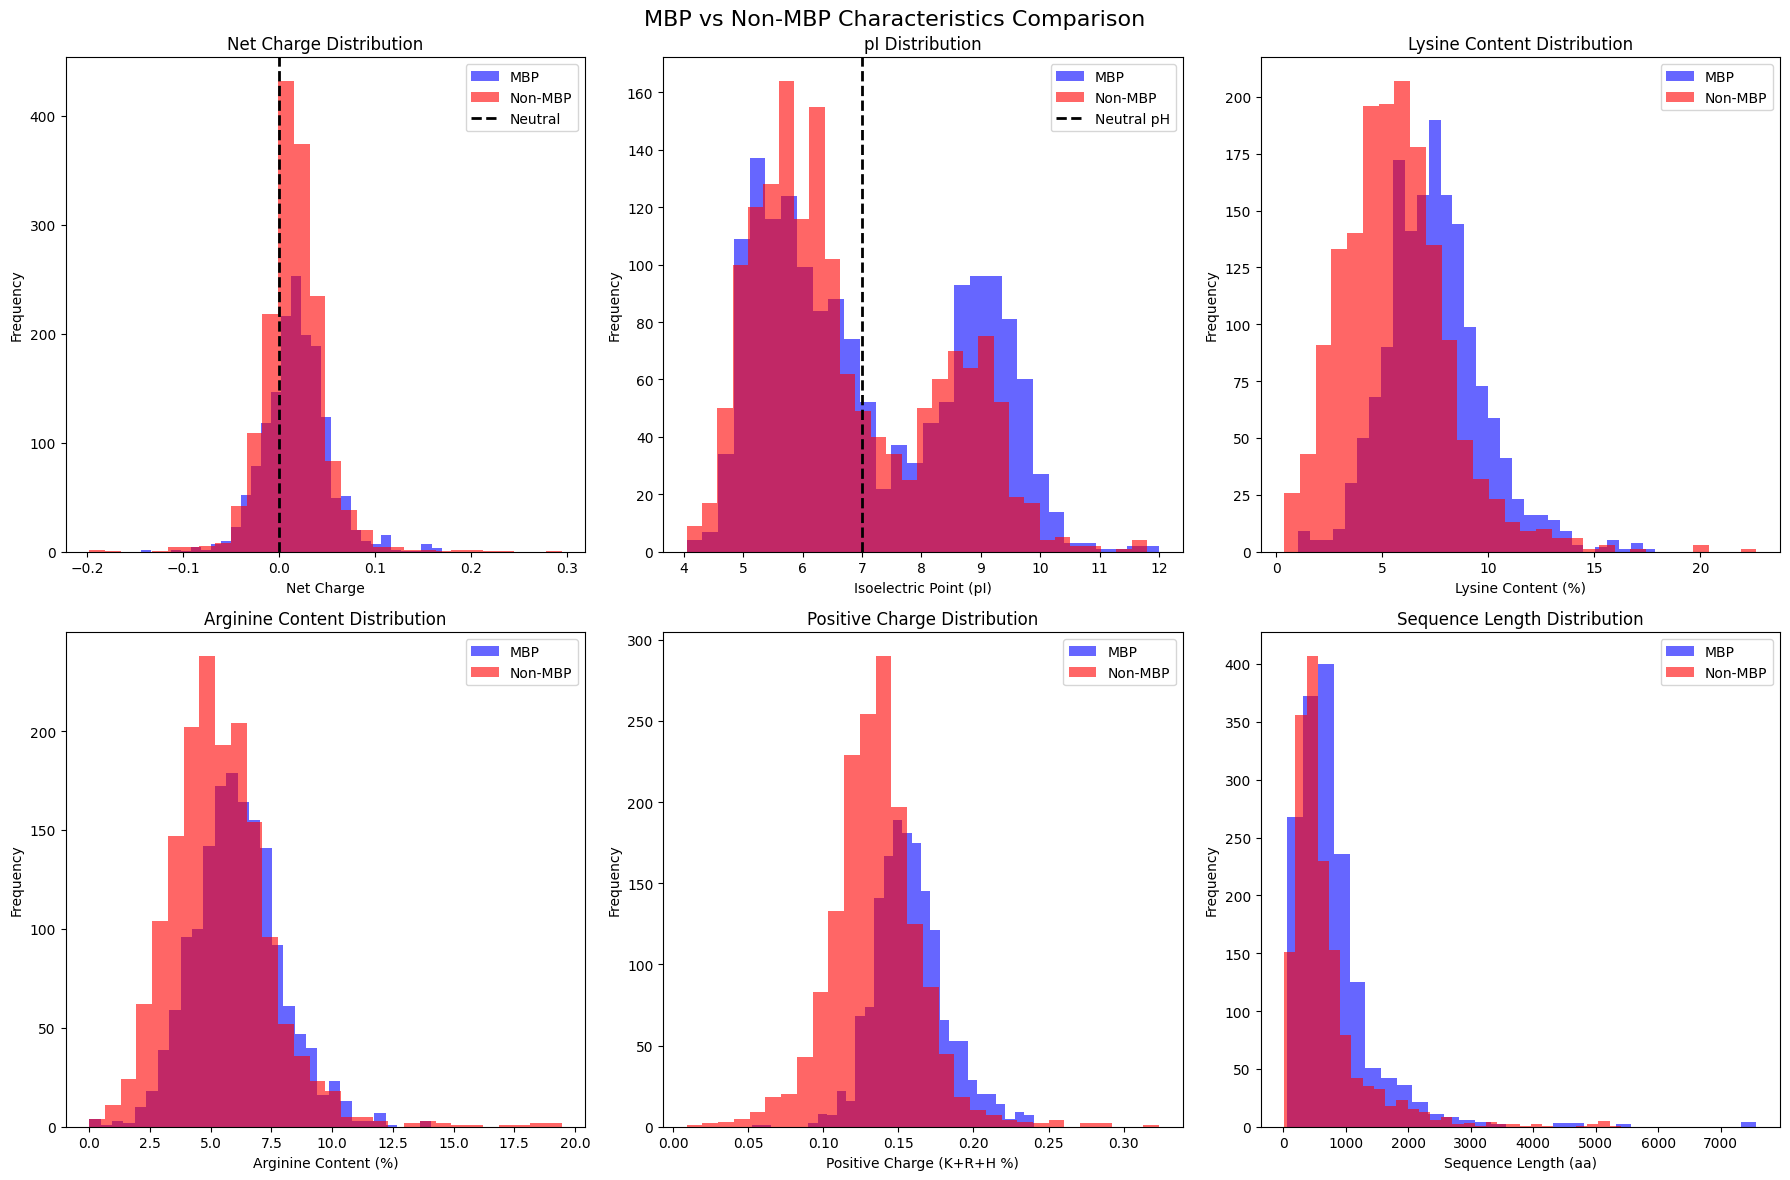


Visualization saved as 'training_data_analysis.png'

SAMPLE SEQUENCES FOR MANUAL VERIFICATION

Random MBP samples (check if these are actually microtubule-binding):

Q8VDS7:
  Length: 400 aa
  Net Charge: 0.04
  pI: 8.62
  K+R: 17.2%

Q61J98:
  Length: 791 aa
  Net Charge: 0.04
  pI: 9.45
  K+R: 13.5%

Q9WV86:
  Length: 491 aa
  Net Charge: 0.02
  pI: 7.11
  K+R: 14.9%

P56536:
  Length: 955 aa
  Net Charge: 0.01
  pI: 5.86
  K+R: 15.7%

Q9LPC6:
  Length: 894 aa
  Net Charge: 0.02
  pI: 6.58
  K+R: 13.4%

FINAL DIAGNOSIS

❌ Found 1 potential issues with training data:
   1. WARNING: Low basic amino acid content

⚠️  RECOMMENDATIONS:
   1. Verify the source of your MBP labels
   2. Check if you're confusing different 'MBP' types:
      - Microtubule-Binding Proteins (your target)
      - Myelin Basic Protein
      - Maltose-Binding Protein
   3. Look up a few Protein IDs in UniProt to confirm function
   4. Consider re-curating your training data


Detailed properties saved to: trainin

In [14]:
# ============================================================================
# VERIFY TRAINING DATA QUALITY - Microtubule-Binding Proteins
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import os
from google.colab import drive

# Mount and navigate
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/MBP_PREDICTOR')

print("="*60)
print("VERIFYING TRAINING DATA QUALITY")
print("="*60)

# Load data
df = pd.read_csv("data/mbp_dataset.csv")

print(f"\nDataset Overview:")
print(f"Total sequences: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Check labels
print(f"\nClass Distribution:")
print(df['Label'].value_counts())
print(f"MBP (1): {(df['Label'] == 1).sum()}")
print(f"Non-MBP (0): {(df['Label'] == 0).sum()}")
print(f"Balance ratio: {(df['Label'] == 1).sum() / (df['Label'] == 0).sum():.3f}")

# ============================================================================
# ANALYZE MBP CHARACTERISTICS
# ============================================================================

print("\n" + "="*60)
print("ANALYZING MICROTUBULE-BINDING PROTEIN CHARACTERISTICS")
print("="*60)

def analyze_sequence_properties(sequence):
    """Calculate key properties for a sequence"""
    try:
        analysis = ProteinAnalysis(sequence)

        # Amino acid composition
        aa_comp = analysis.get_amino_acids_percent()

        # Charge properties
        charge_pos = aa_comp.get('K', 0) + aa_comp.get('R', 0) + aa_comp.get('H', 0)
        charge_neg = aa_comp.get('D', 0) + aa_comp.get('E', 0)
        net_charge = charge_pos - charge_neg

        # pI
        pi = analysis.isoelectric_point()

        # Hydrophobicity
        hydro = analysis.gravy()

        return {
            'Length': len(sequence),
            'Lysine': aa_comp.get('K', 0),
            'Arginine': aa_comp.get('R', 0),
            'Pos_Charge': charge_pos,
            'Neg_Charge': charge_neg,
            'Net_Charge': net_charge,
            'pI': pi,
            'Hydrophobicity': hydro,
            'Proline': aa_comp.get('P', 0),
            'Glycine': aa_comp.get('G', 0)
        }
    except:
        return None

print("\nCalculating biochemical properties for all sequences...")
properties = []
failed = 0

for idx, row in df.iterrows():
    props = analyze_sequence_properties(row['Sequence'])
    if props:
        props['Label'] = row['Label']
        props['Protein_ID'] = row['Protein_ID']
        properties.append(props)
    else:
        failed += 1

    if (idx + 1) % 500 == 0:
        print(f"  Processed {idx + 1}/{len(df)}...")

print(f"Successfully analyzed: {len(properties)}")
print(f"Failed: {failed}")

props_df = pd.DataFrame(properties)

# ============================================================================
# COMPARE MBP vs NON-MBP CHARACTERISTICS
# ============================================================================

print("\n" + "="*60)
print("COMPARISON: MBP vs NON-MBP")
print("="*60)

mbp_props = props_df[props_df['Label'] == 1]
non_mbp_props = props_df[props_df['Label'] == 0]

print(f"\n{'Property':<20} {'MBP Mean':<15} {'Non-MBP Mean':<15} {'Difference':<15}")
print("-" * 65)

for col in ['Length', 'Lysine', 'Arginine', 'Pos_Charge', 'Net_Charge', 'pI', 'Hydrophobicity', 'Proline', 'Glycine']:
    mbp_mean = mbp_props[col].mean()
    non_mbp_mean = non_mbp_props[col].mean()
    diff = mbp_mean - non_mbp_mean
    print(f"{col:<20} {mbp_mean:<15.4f} {non_mbp_mean:<15.4f} {diff:<15.4f}")

# ============================================================================
# EXPECTED CHARACTERISTICS FOR TRUE MICROTUBULE-BINDING PROTEINS
# ============================================================================

print("\n" + "="*60)
print("EXPECTED vs OBSERVED CHARACTERISTICS")
print("="*60)

print("\nExpected for TRUE Microtubule-Binding Proteins:")
print("  - HIGH positive charge (Lysine + Arginine rich)")
print("  - Basic pI (> 8.0)")
print("  - Positive net charge")
print("  - Rich in basic amino acids (K, R)")
print("  - Proline-rich regions common")

print("\nObserved in your MBP class:")
print(f"  - Lysine content: {mbp_props['Lysine'].mean():.4f} ({mbp_props['Lysine'].mean()*100:.2f}%)")
print(f"  - Arginine content: {mbp_props['Arginine'].mean():.4f} ({mbp_props['Arginine'].mean()*100:.2f}%)")
print(f"  - Positive charge: {mbp_props['Pos_Charge'].mean():.4f}")
print(f"  - Net charge: {mbp_props['Net_Charge'].mean():.4f}")
print(f"  - Average pI: {mbp_props['pI'].mean():.2f}")

# Check if characteristics match expectations
print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

issues = []

# Check 1: Net charge
if mbp_props['Net_Charge'].mean() < 0:
    issues.append("WARNING: MBPs have NEGATIVE net charge on average")
    print("\n❌ ISSUE 1: Net Charge")
    print(f"   Your MBPs have average net charge: {mbp_props['Net_Charge'].mean():.2f}")
    print("   Expected: Positive charge for microtubule binding")
else:
    print("\n✅ Net Charge looks reasonable")

# Check 2: pI
if mbp_props['pI'].mean() < 7.0:
    issues.append("WARNING: MBPs have ACIDIC pI on average")
    print("\n❌ ISSUE 2: Isoelectric Point")
    print(f"   Your MBPs have average pI: {mbp_props['pI'].mean():.2f}")
    print("   Expected: Basic pI (> 8.0) for microtubule binding")
else:
    print("\n✅ pI looks reasonable")

# Check 3: Basic amino acids
basic_content = mbp_props['Lysine'].mean() + mbp_props['Arginine'].mean()
if basic_content < 0.15:  # Less than 15% combined K+R
    issues.append("WARNING: Low basic amino acid content")
    print("\n❌ ISSUE 3: Basic Amino Acids")
    print(f"   Your MBPs have K+R: {basic_content*100:.2f}%")
    print("   Expected: > 15% for strong microtubule binding")
else:
    print("\n✅ Basic amino acid content looks reasonable")

# Check 4: Overlap between classes
print("\n" + "="*60)
print("CLASS SEPARATION ANALYSIS")
print("="*60)

# Calculate overlap
for prop in ['Net_Charge', 'pI', 'Lysine', 'Arginine']:
    mbp_vals = mbp_props[prop].values
    non_mbp_vals = non_mbp_props[prop].values

    # Simple overlap metric
    mbp_range = (mbp_vals.min(), mbp_vals.max())
    non_mbp_range = (non_mbp_vals.min(), non_mbp_vals.max())

    overlap = max(0, min(mbp_range[1], non_mbp_range[1]) - max(mbp_range[0], non_mbp_range[0]))
    total_range = max(mbp_range[1], non_mbp_range[1]) - min(mbp_range[0], non_mbp_range[0])
    overlap_pct = (overlap / total_range) * 100

    print(f"\n{prop}:")
    print(f"  MBP range: [{mbp_range[0]:.2f}, {mbp_range[1]:.2f}]")
    print(f"  Non-MBP range: [{non_mbp_range[0]:.2f}, {non_mbp_range[1]:.2f}]")
    print(f"  Overlap: {overlap_pct:.1f}%")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('MBP vs Non-MBP Characteristics Comparison', fontsize=16)

# Plot 1: Net Charge
axes[0,0].hist(mbp_props['Net_Charge'], bins=30, alpha=0.6, label='MBP', color='blue')
axes[0,0].hist(non_mbp_props['Net_Charge'], bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[0,0].axvline(0, color='black', linestyle='--', linewidth=2, label='Neutral')
axes[0,0].set_xlabel('Net Charge')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Net Charge Distribution')
axes[0,0].legend()

# Plot 2: pI
axes[0,1].hist(mbp_props['pI'], bins=30, alpha=0.6, label='MBP', color='blue')
axes[0,1].hist(non_mbp_props['pI'], bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[0,1].axvline(7.0, color='black', linestyle='--', linewidth=2, label='Neutral pH')
axes[0,1].set_xlabel('Isoelectric Point (pI)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('pI Distribution')
axes[0,1].legend()

# Plot 3: Lysine content
axes[0,2].hist(mbp_props['Lysine']*100, bins=30, alpha=0.6, label='MBP', color='blue')
axes[0,2].hist(non_mbp_props['Lysine']*100, bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[0,2].set_xlabel('Lysine Content (%)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Lysine Content Distribution')
axes[0,2].legend()

# Plot 4: Arginine content
axes[1,0].hist(mbp_props['Arginine']*100, bins=30, alpha=0.6, label='MBP', color='blue')
axes[1,0].hist(non_mbp_props['Arginine']*100, bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[1,0].set_xlabel('Arginine Content (%)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Arginine Content Distribution')
axes[1,0].legend()

# Plot 5: Positive charge
axes[1,1].hist(mbp_props['Pos_Charge'], bins=30, alpha=0.6, label='MBP', color='blue')
axes[1,1].hist(non_mbp_props['Pos_Charge'], bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[1,1].set_xlabel('Positive Charge (K+R+H %)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Positive Charge Distribution')
axes[1,1].legend()

# Plot 6: Length
axes[1,2].hist(mbp_props['Length'], bins=30, alpha=0.6, label='MBP', color='blue')
axes[1,2].hist(non_mbp_props['Length'], bins=30, alpha=0.6, label='Non-MBP', color='red')
axes[1,2].set_xlabel('Sequence Length (aa)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Sequence Length Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('training_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'training_data_analysis.png'")

# ============================================================================
# SAMPLE SEQUENCES FOR MANUAL VERIFICATION
# ============================================================================

print("\n" + "="*60)
print("SAMPLE SEQUENCES FOR MANUAL VERIFICATION")
print("="*60)

print("\nRandom MBP samples (check if these are actually microtubule-binding):")
mbp_samples = mbp_props.sample(min(5, len(mbp_props)))
for idx, row in mbp_samples.iterrows():
    print(f"\n{row['Protein_ID']}:")
    print(f"  Length: {row['Length']} aa")
    print(f"  Net Charge: {row['Net_Charge']:.2f}")
    print(f"  pI: {row['pI']:.2f}")
    print(f"  K+R: {(row['Lysine'] + row['Arginine'])*100:.1f}%")

# ============================================================================
# FINAL DIAGNOSIS
# ============================================================================

print("\n" + "="*60)
print("FINAL DIAGNOSIS")
print("="*60)

if len(issues) == 0:
    print("\n✅ Your training data appears to be correctly labeled")
    print("   The MBP class shows expected characteristics for microtubule-binding proteins")
else:
    print(f"\n❌ Found {len(issues)} potential issues with training data:")
    for i, issue in enumerate(issues, 1):
        print(f"   {i}. {issue}")

    print("\n⚠️  RECOMMENDATIONS:")
    print("   1. Verify the source of your MBP labels")
    print("   2. Check if you're confusing different 'MBP' types:")
    print("      - Microtubule-Binding Proteins (your target)")
    print("      - Myelin Basic Protein")
    print("      - Maltose-Binding Protein")
    print("   3. Look up a few Protein IDs in UniProt to confirm function")
    print("   4. Consider re-curating your training data")

print("\n" + "="*60)

# Save detailed report
props_df.to_csv("training_data_properties.csv", index=False)
print("\nDetailed properties saved to: training_data_properties.csv")